# 02 — CNN-LSTM: Spatio-Temporal Flood Prediction

**Research question:** Can the *spatio-temporal pattern* of rainfall (not just its peak intensity) predict urban pluvial floods?

---

## Why CNN-LSTM?

The tabular baseline (notebook 01) used only 7 scalar features (max intensity at 7 duration windows).  
These aggregations discard two types of information that may distinguish flood-causing rain from non-flood rain:

- **Spatial pattern** — Is rain concentrated in one corner of the basin, or uniform?
- **Temporal shape** — Does intensity spike suddenly, or build gradually over hours?

The IMERG matrix `(T, H, W)` preserves both. This model learns directly from it.

---

## Architecture

```
imerg_matrix  (T, H, W)           — raw satellite rainfall field
imerg_mask    (H, W)              — binary polygon mask
       │
  [mask applied]                  — zeros out pixels outside the flood polygon
  [pad to (MAX_T, MAX_DIM, MAX_DIM)]
       │
  ┌────────────────────────────┐
  │  CNN  (shared across time) │  — same weights applied to every time step
  │                            │
  │  Conv2d(1 → 16, 3×3)      │
  │  ReLU                      │
  │  Conv2d(16 → 32, 3×3)     │
  │  ReLU → MaxPool2d(2×2)    │
  │  Flatten → Linear(→ 128)  │
  │  ReLU                      │
  └────────────┬───────────────┘
               │  (T, 128)       — one feature vector per time step
               │
          ┌────▼────┐
          │  LSTM   │            — learns how the rainfall pattern evolves
          │ (64 hid)│
          └────┬────┘
               │  last hidden state  (64,)
               │
         Linear(64 → 1)
               │
           Sigmoid
               │
         is_flood  (0 / 1)
```

### Key design choices

| Choice | Reason |
|--------|--------|
| Shared CNN weights across time | The spatial filter should mean the same thing at t=0 and t=100 |
| MaxPool2d (not AvgPool) | Captures *where* rain is most intense, not the diluted average |
| MAX_DIM filter | Excludes very large basins where IMERG pixels are too coarse relative to basin area |
| Pad to fixed size | Allows batching of variable (H, W) matrices |
| BCEWithLogitsLoss | Numerically stable; pos_weight handles class imbalance |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils import resample
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score,
)

# ── CONFIGURATION ─────────────────────────────────────────────────
FULL_PATH = r"D:\Development\RESEARCH\urban_flood_database\chronicle\unified_ml_dataset_FULL.pkl"

# Filters (same as tabular baseline)
URBAN_THRESHOLD        = 20.0
THRESH_1H              = 7.0
THRESH_24H             = 1.0
PFDI_PLUVIAL_THRESHOLD = 1.0

# Spatial filter: exclude basins whose bounding box exceeds MAX_DIM × MAX_DIM pixels.
# At 0.1° resolution (~10 km/pixel), MAX_DIM=10 corresponds to a ~100×100 km bounding box.
# Larger basins are excluded because a single IMERG pixel already covers ~100 km²,
# making spatial patterns within a giant basin physically meaningless at this resolution.
MAX_DIM = 10

# Temporal: pad / truncate to MAX_T time steps.
# IMERG is at 30-min intervals; the extraction window is 96h → 192 steps.
MAX_T = 48

# Undersampling ratio (flood : no-flood) — based on tabular model exploration
UNDERSAMPLE_RATIO = 3

# Model hyper-parameters
CNN_CHANNELS = [16, 32]   # filters in conv layer 1 and 2
FC_SIZE      = 128        # CNN output feature vector size
HIDDEN_SIZE  = 64         # LSTM hidden units

# Training
BATCH_SIZE   = 16
EPOCHS       = 30
LR           = 1e-3
RANDOM_STATE = 42

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"Spatial filter: max {MAX_DIM}×{MAX_DIM} pixels (~{MAX_DIM*10}×{MAX_DIM*10} km bounding box)")

Device: cpu
Spatial filter: max 10×10 pixels (~100×100 km bounding box)


In [2]:
# ── LOAD & FILTER ─────────────────────────────────────────────────
print("Loading FULL dataset (this may take a moment)...")
df = pd.read_pickle(FULL_PATH)

# Standard event filters
filtered_df = df[
    (df['urban_percentage']         >= URBAN_THRESHOLD) &
    (df['60_max_rainfall_intens']   >  THRESH_1H) &
    (df['1440_max_rainfall_intens'] >  THRESH_24H) &
    (df['PFDI_p99']                 <  PFDI_PLUVIAL_THRESHOLD)
].copy()

# Drop events with missing or invalid matrices
filtered_df = filtered_df[filtered_df['imerg_matrix'].apply(
    lambda m: isinstance(m, np.ndarray) and m.ndim == 3 and m.shape[0] > 0
)].copy()

# Extract spatial dimensions from each matrix
filtered_df['mat_H'] = filtered_df['imerg_matrix'].apply(lambda m: m.shape[1])
filtered_df['mat_W'] = filtered_df['imerg_matrix'].apply(lambda m: m.shape[2])

n_before = len(filtered_df)

# Spatial size filter: exclude oversized basins
filtered_df = filtered_df[
    (filtered_df['mat_H'] <= MAX_DIM) &
    (filtered_df['mat_W'] <= MAX_DIM) &
    (filtered_df['mat_H'] > 0) &
    (filtered_df['mat_W'] > 0)
].copy()

n_flood    = (filtered_df['is_flood'] == 1).sum()
n_no_flood = (filtered_df['is_flood'] == 0).sum()

print(f"After standard filters:      {n_before:,} events")
print(f"After spatial filter (≤{MAX_DIM}px): {len(filtered_df):,} events")
print(f"  Flood (1):    {n_flood:,}  ({n_flood/len(filtered_df)*100:.1f}%)")
print(f"  No-flood (0): {n_no_flood:,}  ({n_no_flood/len(filtered_df)*100:.1f}%)")

# Basin ID for grouped split (prevent spatial leakage)
filtered_df['original_basin_id'] = (
    filtered_df['event_id'].apply(lambda x: str(x).split('_noflood_')[0])
)

# Distribution of spatial sizes
print("\nSpatial size distribution (H × W):")
print(filtered_df[['mat_H', 'mat_W']].describe().round(1))

Loading FULL dataset (this may take a moment)...
After standard filters:      34,101 events
After spatial filter (≤10px): 34,081 events
  Flood (1):    32,665  (95.8%)
  No-flood (0): 1,416  (4.2%)

Spatial size distribution (H × W):
         mat_H    mat_W
count  34081.0  34081.0
mean       1.5      1.5
std        0.8      0.8
min        1.0      1.0
25%        1.0      1.0
50%        1.0      1.0
75%        2.0      2.0
max       10.0     10.0


In [3]:
# ── DATASET ───────────────────────────────────────────────────────
class FloodDataset(Dataset):
    """
    Yields (tensor, label) pairs for the CNN-LSTM model.

    Processing per sample:
      1. Apply imerg_mask  — zeros out pixels outside the flood polygon
      2. Truncate / pad T  — ensures fixed sequence length MAX_T
      3. Pad H, W          — ensures fixed spatial size MAX_DIM × MAX_DIM
    """
    def __init__(self, df: pd.DataFrame, max_t: int, max_dim: int):
        self.df      = df.reset_index(drop=True)
        self.max_t   = max_t
        self.max_dim = max_dim

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        matrix = row['imerg_matrix'].astype(np.float32)  # (T, H, W)
        mask   = row['imerg_mask'].astype(np.float32)    # (H, W)
        label  = float(row['is_flood'])

        # 1. Apply mask: zero out everything outside the polygon
        masked = matrix * mask[np.newaxis, :, :]         # (T, H, W)

        # 2. Truncate or pad along the time axis
        T = masked.shape[0]
        if T > self.max_t:
            masked = masked[:self.max_t]
        elif T < self.max_t:
            pad_t  = self.max_t - T
            masked = np.pad(masked, ((0, pad_t), (0, 0), (0, 0)))

        # 3. Pad spatial dims to MAX_DIM × MAX_DIM (bottom-right padding)
        H, W   = masked.shape[1], masked.shape[2]
        pad_h  = self.max_dim - H
        pad_w  = self.max_dim - W
        masked = np.pad(masked, ((0, 0), (0, pad_h), (0, pad_w)))

        x = torch.tensor(masked, dtype=torch.float32)   # (MAX_T, MAX_DIM, MAX_DIM)
        y = torch.tensor(label,  dtype=torch.float32)
        return x, y

print("FloodDataset class defined.")

FloodDataset class defined.


In [4]:
# ── MODEL ARCHITECTURE ────────────────────────────────────────────
class CNN_LSTM(nn.Module):
    """
    Spatio-temporal model for flood prediction.

    Step 1 — Shared CNN:
        Applied independently to each time step (shared weights).
        Extracts a spatial feature vector from the masked rainfall field.
        Input:  (batch × T,  1,        MAX_DIM, MAX_DIM)
        Output: (batch × T,  FC_SIZE)

    Step 2 — LSTM:
        Receives the sequence of spatial feature vectors.
        Learns how the rainfall pattern evolves in the hours before the event.
        Input:  (batch, T, FC_SIZE)
        Output: last hidden state  (batch, HIDDEN_SIZE)

    Step 3 — Classification head:
        Input:  (batch, HIDDEN_SIZE)
        Output: (batch, 1)  — raw logit; apply sigmoid for probability.
    """
    def __init__(self, max_dim, cnn_channels, fc_size, hidden_size):
        super().__init__()

        # Shared 2-D CNN
        self.cnn = nn.Sequential(
            nn.Conv2d(1, cnn_channels[0], kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(cnn_channels[0], cnn_channels[1], kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # halves H and W — keeps peak intensity, discards diluted average
        )

        # Flat size after MaxPool
        pooled_h   = max_dim // 2
        pooled_w   = max_dim // 2
        flat_size  = cnn_channels[1] * pooled_h * pooled_w

        # Projection to fixed-size feature vector
        self.cnn_fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_size, fc_size),
            nn.ReLU(),
        )

        # LSTM — processes the temporal sequence
        self.lstm = nn.LSTM(
            input_size=fc_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
        )

        # Binary output (logit — sigmoid applied outside during inference)
        self.fc_out = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, T, H, W)
        batch, T, H, W = x.shape

        # Reshape: treat every time step as a separate image for the CNN
        x = x.view(batch * T, 1, H, W)     # (batch*T, 1, H, W)
        x = self.cnn(x)                     # (batch*T, C, H', W')
        x = self.cnn_fc(x)                  # (batch*T, fc_size)

        # Reshape back into a time sequence
        x = x.view(batch, T, -1)            # (batch, T, fc_size)

        # LSTM: only the final hidden state carries the temporal summary
        _, (h_n, _) = self.lstm(x)          # h_n: (1, batch, hidden_size)
        x = h_n.squeeze(0)                  # (batch, hidden_size)

        return self.fc_out(x)               # (batch, 1) — raw logit


# Instantiate and print summary
model = CNN_LSTM(
    max_dim=MAX_DIM,
    cnn_channels=CNN_CHANNELS,
    fc_size=FC_SIZE,
    hidden_size=HIDDEN_SIZE,
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTotal trainable parameters: {total_params:,}")

CNN_LSTM(
  (cnn): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (cnn_fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=800, out_features=128, bias=True)
    (2): ReLU()
  )
  (lstm): LSTM(128, 64, batch_first=True)
  (fc_out): Linear(in_features=64, out_features=1, bias=True)
)

Total trainable parameters: 157,057


In [5]:
# ── SPLIT & UNDERSAMPLE & DATALOADERS ─────────────────────────────

# Grouped split: all events from the same basin go to the same split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(
    filtered_df, filtered_df['is_flood'], filtered_df['original_basin_id']
))

train_df = filtered_df.iloc[train_idx].copy()
test_df  = filtered_df.iloc[test_idx].copy()

# Undersample flood events in the training set
n_no_flood_train = (train_df['is_flood'] == 0).sum()
n_flood_keep     = min(n_no_flood_train * UNDERSAMPLE_RATIO,
                       (train_df['is_flood'] == 1).sum())

flood_down = resample(
    train_df[train_df['is_flood'] == 1],
    replace=False, n_samples=n_flood_keep, random_state=RANDOM_STATE
)
train_bal_df = pd.concat([flood_down, train_df[train_df['is_flood'] == 0]])

print(f"Balanced training set (ratio {UNDERSAMPLE_RATIO}:1):")
print(f"  Flood:    {(train_bal_df['is_flood']==1).sum():,}")
print(f"  No-flood: {(train_bal_df['is_flood']==0).sum():,}")
print(f"  Total:    {len(train_bal_df):,}")
print(f"\nTest set: {len(test_df):,} events")

# DataLoaders
train_dataset = FloodDataset(train_bal_df, MAX_T, MAX_DIM)
test_dataset  = FloodDataset(test_df,  MAX_T, MAX_DIM)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"\nTrain batches: {len(train_loader)} | Test batches: {len(test_loader)}")

Balanced training set (ratio 3:1):
  Flood:    3,087
  No-flood: 1,029
  Total:    4,116

Test set: 6,918 events

Train batches: 258 | Test batches: 433


In [6]:
# ── TRAINING ──────────────────────────────────────────────────────

# pos_weight: upweights the flood class in the loss.
# Even after undersampling, a small correction helps because BCEWithLogitsLoss
# treats both classes equally by default.
n_neg = (train_bal_df['is_flood'] == 0).sum()
n_pos = (train_bal_df['is_flood'] == 1).sum()
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)


def run_epoch(model, loader, optimizer, criterion, device, training: bool):
    model.train() if training else model.eval()
    total_loss = 0.0
    all_labels, all_probs = [], []

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch).squeeze(1)         # (batch,)
            loss   = criterion(logits, y_batch)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item()
            probs = torch.sigmoid(logits).cpu().detach().numpy()
            all_probs.extend(probs)
            all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader)
    return avg_loss, np.array(all_labels), np.array(all_probs)


# Training loop
history = {'train_loss': [], 'val_loss': []}

print(f"Training for {EPOCHS} epochs on {device}...\n")
for epoch in range(1, EPOCHS + 1):
    train_loss, _, _       = run_epoch(model, train_loader, optimizer, criterion, device, training=True)
    val_loss, _, _         = run_epoch(model, test_loader,  optimizer, criterion, device, training=False)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f}")

print("\nTraining complete.")

Training for 30 epochs on cpu...

Epoch   1/30 | Train loss: 0.3395 | Val loss: 0.2582
Epoch   5/30 | Train loss: 0.3138 | Val loss: 0.2414
Epoch  10/30 | Train loss: 0.3064 | Val loss: 0.2313
Epoch  15/30 | Train loss: 0.3001 | Val loss: 0.2303
Epoch  20/30 | Train loss: 0.3037 | Val loss: 0.2450
Epoch  25/30 | Train loss: 0.3002 | Val loss: 0.2270
Epoch  30/30 | Train loss: 0.2970 | Val loss: 0.2558

Training complete.


── CNN-LSTM — Test Set Classification Report ───────────────
              precision    recall  f1-score   support

    No Flood       0.06      0.35      0.10       387
       Flood       0.95      0.66      0.78      6531

    accuracy                           0.65      6918
   macro avg       0.50      0.51      0.44      6918
weighted avg       0.90      0.65      0.74      6918



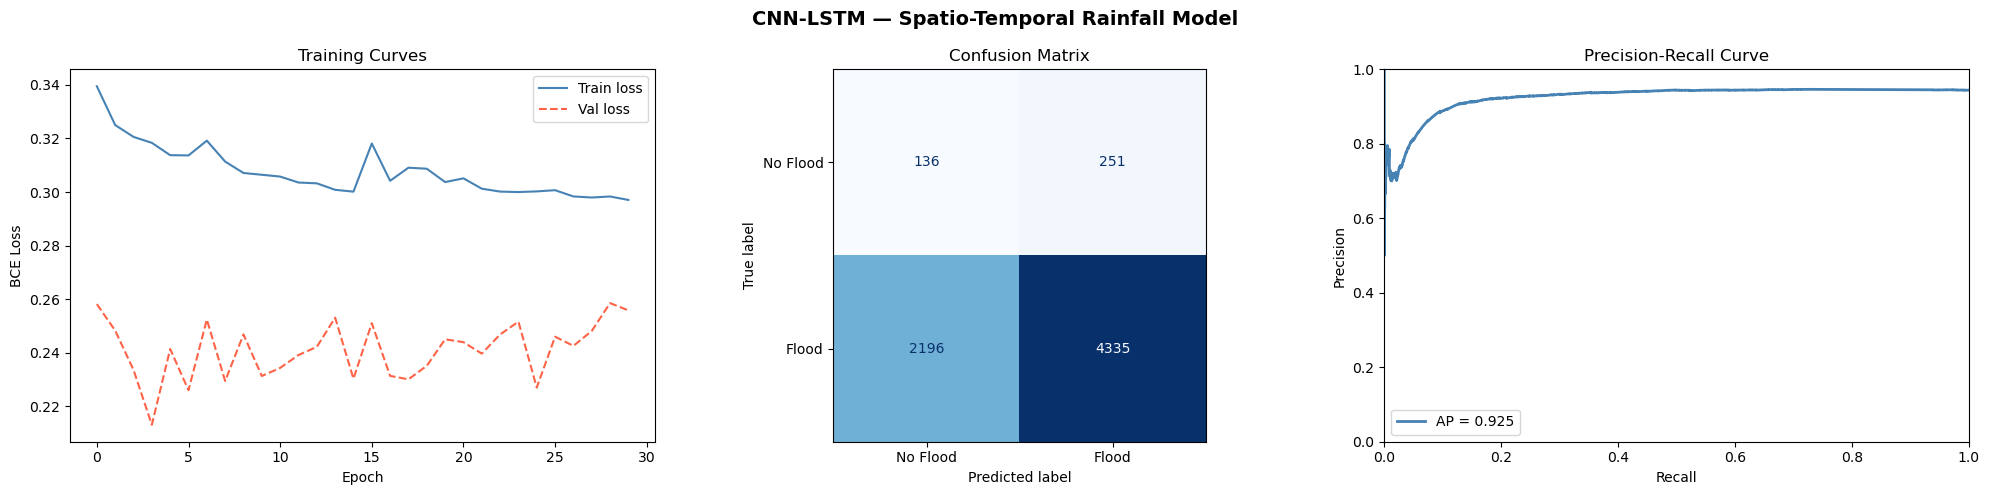

── CNN-LSTM — Train Set Performance (overfitting check) ────
              precision    recall  f1-score   support

    No Flood       0.35      0.54      0.42      1029
       Flood       0.81      0.66      0.73      3087

    accuracy                           0.63      4116
   macro avg       0.58      0.60      0.58      4116
weighted avg       0.70      0.63      0.65      4116



In [7]:
# ── EVALUATION ────────────────────────────────────────────────────
_, y_true, y_proba = run_epoch(model, test_loader, optimizer, criterion, device, training=False)
y_pred = (y_proba >= 0.5).astype(int)

print("── CNN-LSTM — Test Set Classification Report ───────────────")
print(classification_report(y_true, y_pred, target_names=['No Flood', 'Flood']))

# Plots
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('CNN-LSTM — Spatio-Temporal Rainfall Model', fontsize=14, fontweight='bold')

# A: Training curves
axes[0].plot(history['train_loss'], label='Train loss', color='steelblue')
axes[0].plot(history['val_loss'],   label='Val loss',   color='tomato', linestyle='--')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss')
axes[0].set_title('Training Curves')
axes[0].legend()

# B: Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No Flood', 'Flood']).plot(
    ax=axes[1], cmap='Blues', colorbar=False
)
axes[1].set_title('Confusion Matrix')
axes[1].grid(False)

# C: Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_true, y_proba)
ap = average_precision_score(y_true, y_proba)
axes[2].plot(recall, precision, lw=2, color='steelblue', label=f'AP = {ap:.3f}')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve')
axes[2].legend()
axes[2].set_xlim([0, 1])
axes[2].set_ylim([0, 1])

plt.tight_layout()
plt.show()

# Sanity check: train set performance
print("── CNN-LSTM — Train Set Performance (overfitting check) ────")
_, y_true_tr, y_proba_tr = run_epoch(model, train_loader, optimizer, criterion, device, training=False)
y_pred_tr = (y_proba_tr >= 0.5).astype(int)
print(classification_report(y_true_tr, y_pred_tr, target_names=['No Flood', 'Flood']))